In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [91]:
maru_data = pd.read_csv("maru_data.csv")

In [93]:
maru_data

,segments,contact_cost,response_rate,workers_needed,worker_labor_cost_per_hr,instructors_needed,instructor_labor_cost_per_hr,price_per_hr,annual_hours,retention_rate,interest_rate
0,little leaguers,1000,0.100,2,1500,1,3000,6500,10.0,0.75,0.1
1,summer sluggers,1500,0.150,1,1500,0,0,3000,4.0,0.50,0.1
2,elite ballplayers (print ad),300,0.005,1,1500,1,4500,7500,20.0,0.60,0.1
3,elite ballplayers (party),12500,0.250,1,1500,1,4500,7500,20.0,0.60,0.1
4,entertainment seekers,50,0.025,2,1500,0,0,4000,1.5,0.35,0.1


# **Part I: Case Questions**

## **Calculate annual margin**

In [24]:
maru_data['total_cost_per_hr'] = (maru_data['instructor_labor_cost_per_hr'] * maru_data['instructors_needed'] +
                                  maru_data['worker_labor_cost_per_hr'] * maru_data['workers_needed'])
maru_data['margin_hr'] = maru_data['price_per_hr'] - maru_data['total_cost_per_hr']
maru_data['annual_margin'] = maru_data['margin_hr'] * maru_data['annual_hours']

In [26]:
maru_data['annual_margin']

0     5000.0
1     6000.0
2    30000.0
3    30000.0
4     1500.0
Name: annual_margin, dtype: float64

## **Case Q1: Calculate aquisition cost**

In [29]:
maru_data['acquisition_cost'] = maru_data['contact_cost'] / maru_data['response_rate']
maru_data['acquisition_cost']

0    10000.0
1    10000.0
2    60000.0
3    50000.0
4     2000.0
Name: acquisition_cost, dtype: float64

## **Case Q3: Calculating Customer Lifetime Value (CLV) with Infinite Time Horizon**
The formula used is:

$$
\text{Net CLV} = \left(M \times \frac{(1 + i)}{(1 + i - R)}\right) - \text{AC}
$$

where:
- **`M`**: The annual margin for each customer.
- **`i`**: The interest rate (or discount rate).
- **`R`**: The retention rate, or the probability of a customer staying each period.
- **`AC`**: The acquisition cost per customer.


In [32]:
maru_data['clv'] = (maru_data['annual_margin'] *
                    ((1 + maru_data['interest_rate']) / (1 + maru_data['interest_rate'] - maru_data['retention_rate'])) -
                    maru_data['acquisition_cost'])

In [34]:
maru_data['clv']

0     5714.285714
1     1000.000000
2     6000.000000
3    16000.000000
4      200.000000
Name: clv, dtype: float64

## **Case Q4: The most attractive customer segment**

In [25]:
most_attractive_CS = maru_data.loc[maru_data['clv'].idxmax(), 'segments']
highest_clv = maru_data['clv'].max()

print("Q4) The most attractive segment is:", most_attractive_CS)
print("     It has a CLV of:", round(highest_clv,3))

Q4) The most attractive segment is: elite ballplayers (party)
     It has a CLV of: 16000.0


#### Answer: As elite ballplayer (party) has the highest CLV amongst all the other segments, we can conclude that it is the most attractive customer segment

## **Case Q5: Chiyoda ward**

In [36]:
minato_ll = maru_data.query("segments == 'little leaguers'").copy().iloc[0]

chiyoda_ll = {
    'segments': 'Little Leaguers (Chiyoda)',
    'workers_needed': 2,
    'instructors_needed': 1,
    'worker_labor_cost_per_hr': 1500,
    'instructor_labor_cost_per_hr': 3000,
    'price_per_hr': 6500,
    'annual_hours': 10,
    'contact_cost': 600,     # vs. 1000 in Minato
    'response_rate': 0.08,   # vs. 0.10
    'retention_rate': 0.65,  # vs. 0.75 in Minato
    'interest_rate': 0.10
}
chiyoda_ll['total_cost_per_hr'] = (chiyoda_ll['workers_needed'] * chiyoda_ll['worker_labor_cost_per_hr']+ chiyoda_ll['instructors_needed'] * chiyoda_ll['instructor_labor_cost_per_hr'])

chiyoda_ll['margin_hr'] = chiyoda_ll['price_per_hr'] - chiyoda_ll['total_cost_per_hr']

chiyoda_ll['annual_margin'] = chiyoda_ll['margin_hr'] * chiyoda_ll['annual_hours']

chiyoda_ll['acquisition_cost'] = chiyoda_ll['contact_cost'] / chiyoda_ll['response_rate']

chiyoda_ll['clv'] = (
    chiyoda_ll['annual_margin'] *
    ((1 + chiyoda_ll['interest_rate']) /
     (1 + chiyoda_ll['interest_rate'] - chiyoda_ll['retention_rate']))
    - chiyoda_ll['acquisition_cost']
)

print("Chiyoda scenario for Little Leaguers:")
for col in ['segments','contact_cost','response_rate','retention_rate','acquisition_cost','clv']:
    print(f"{col}: {chiyoda_ll[col]}")

print("\nExisting Minato-based Little Leaguers row:")
for col in ['segments','contact_cost','response_rate','retention_rate','acquisition_cost','clv']:
    print(f"{col}: {minato_ll[col]}")


Chiyoda scenario for Little Leaguers:
segments: Little Leaguers (Chiyoda)
contact_cost: 600
response_rate: 0.08
retention_rate: 0.65
acquisition_cost: 7500.0
clv: 4722.222222222221

Existing Minato-based Little Leaguers row:
segments: little leaguers
contact_cost: 1000
response_rate: 0.1
retention_rate: 0.75
acquisition_cost: 10000.0
clv: 5714.285714285712


#### Answer: Although each individual Chiyoda Little Leaguer has a lower CLV than one in Minato (due to a lower response rate and lower retention), Chiyoda has twice the total number of players. When you multiply the slightly lower CLV by the much larger customer base, the total profit potential from Chiyoda exceeds that of Minato. Hence, from a purely financial standpoint, MBC should pursue the Chiyoda sponsorship.

## **Case Q6: Elite ballplayers discount**

In [147]:
m = 50000  # Updated annual margin after discount
r = 0.75   # Updated retention rate due to discount
i = 0.10  
m1 = 30000
r1 = 0.60  # Retention rate before discount
acquisition_cost = 50000  

mr_infinite = (m * (1 + i) / (1 + i - r))  # Infinite horizon CLV with discount
mr_discount = (m * (1 + i) / (1 + i))  # Discount adjustment term
m1_discount = (m1 * r1 / (1 + i))  # Year 1 adjustment

clv_discounted = mr_infinite - (m - m1) - acquisition_cost
clv_gala_only = (m1 * (1 + i) / (1 + i - r1)) - acquisition_cost  

print(f"CLV with Discount Plan: {clv_discounted:,.0f} yen")
print(f"CLV with Gala Only Plan: {clv_gala_only:,.0f} yen")

if clv_discounted > clv_gala_only:
    print("\nConclusion: The discount plan yields a higher CLV. Offer the discount!")
else:
    print("\nConclusion: The gala-only plan is better.")

CLV with Discount Plan: 87,143 yen
CLV with Gala Only Plan: 16,000 yen

Conclusion: The discount plan yields a higher CLV. Offer the discount!


#### Answer: MBC should offer this promotion because CLV is higher(87,143) than before(16,000).

# Part II Sensitivity Analysis

In [1]:
baseline_ac = 50000 
baseline_am = 30000 
baseline_rr = 0.60  
interest_rate = 0.10  

In [7]:
# Define alternative values for sensitivity analysis
ac_values = np.array([40000, 45000, 50000, 55000, 60000])  # Acquisition cost scenarios
am_values = np.array([20000, 25000, 30000, 35000, 40000])  # Annual margin scenarios
rr_values = np.array([0.30, 0.45, 0.60, 0.75, 0.90])  # Retention rate scenarios

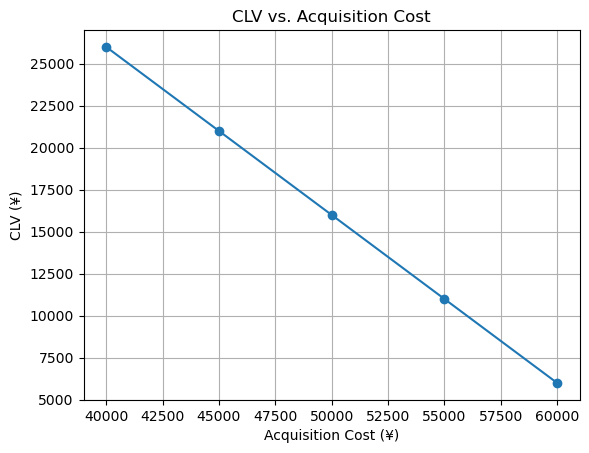

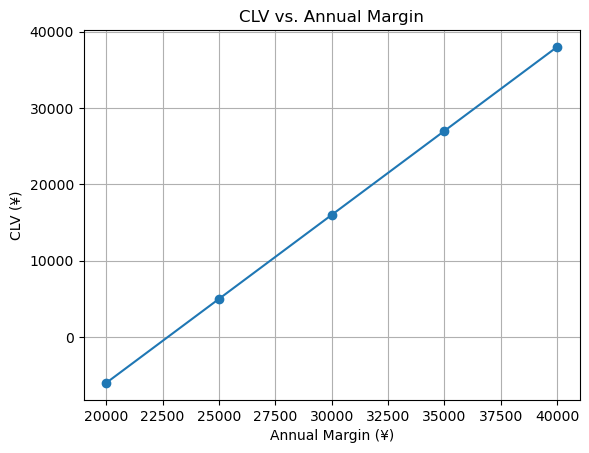

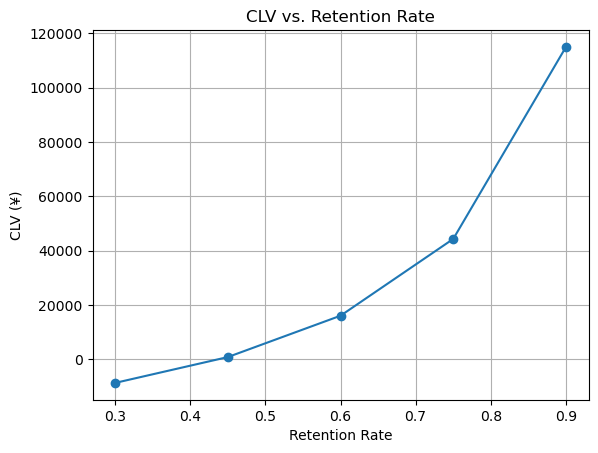

In [11]:
def calculate_clv(ac, am, rr, i):
    """
    Infinite-horizon CLV:
        CLV = ( am * (1 + i) ) / ( (1 + i) - rr ) - ac
    """
    if rr >= (1 + i):
        return np.nan

    discounted_margin_sum = (am * (1 + i)) / ((1 + i) - rr)
    return discounted_margin_sum - ac

clv_ac = [calculate_clv(ac, baseline_am, baseline_rr, interest_rate) 
          for ac in ac_values]

clv_am = [calculate_clv(baseline_ac, am, baseline_rr, interest_rate) 
          for am in am_values]

clv_rr = [calculate_clv(baseline_ac, baseline_am, rr, interest_rate) 
          for rr in rr_values]

# CLV vs. Acquisition Cost
plt.plot(ac_values, clv_ac, marker='o')
plt.title("CLV vs. Acquisition Cost")
plt.xlabel("Acquisition Cost (¥)")
plt.ylabel("CLV (¥)")
plt.grid(True)
plt.show()

# CLV vs. Annual Margin
plt.plot(am_values, clv_am, marker='o')
plt.title("CLV vs. Annual Margin")
plt.xlabel("Annual Margin (¥)")
plt.ylabel("CLV (¥)")
plt.grid(True)
plt.show()

# CLV vs. Retention Rate 
plt.plot(rr_values, clv_rr, marker='o')
plt.title("CLV vs. Retention Rate")
plt.xlabel("Retention Rate")
plt.ylabel("CLV (¥)")
plt.grid(True)
plt.show()

#### What do you notice about the shapes of these three graphs? Do all three variables behave in similar ways?
All three variables behave differently and have different relationship with CLV.
- Acquisition Cost: Shows a linear, negative relationship with CLV, means as acquisition cost increases it reduces overall lifetime value.
- Annual Margin: Also shows a linear, positive relationship ie. higher yearly margins lead to a proportionately higher CLV.
- Retention Rate: Shows a steeply curved (almost exponential) increase—improving retention even slightly yields a large jump in CLV.

### Do some variables seem to be more important than others? What aspects of CLV would be most beneficial to focus on?
Retention Rate seems to be the most powerful driver of CLV because it shows exponential growth. Both reducing acquisition costs and raising annual margin also boost CLV, but not as dramatically as raising retention. So we should focus on improving retention as it provides the biggest impact on lifetime value. (note. retention shows its biggest exponential impact when it’s already relatively high) 



# **Part III Monte Carlo**

# Step 1: Extract values for eli|te ballplayers

In [36]:
elite_ballplayers = maru_data.iloc[3]  # 4th row in zero-indexed Python
ac = elite_ballplayers["acquisition_cost"]
m = elite_ballplayers["annual_margin"]
r = elite_ballplayers["retention_rate"]
elite_ballplayers_clvaggregate = elite_ballplayers["clv"]

In [38]:
ac

50000.0

In [40]:
m

30000.0

In [42]:
r

0.6

# Step 2: Load and analyze customer data for margins

In [44]:
# Load the customer margin data as a DataFrame and convert it to a Series
customers= pd.read_csv("customers.csv", header=None)
customers

,0
0,32101.38188
1,31824.26642
2,36026.44128
3,29321.40836
4,25518.51806
...,...
495,31478.14581
496,30472.63742
497,30422.50571
498,24853.16627


(array([ 3.,  1.,  4.,  7., 13., 17., 26., 37., 49., 39., 65., 65., 53.,
        35., 37., 24., 15.,  3.,  2.,  5.]),
 array([14812.93368 , 16231.514802, 17650.095924, 19068.677046,
        20487.258168, 21905.83929 , 23324.420412, 24743.001534,
        26161.582656, 27580.163778, 28998.7449  , 30417.326022,
        31835.907144, 33254.488266, 34673.069388, 36091.65051 ,
        37510.231632, 38928.812754, 40347.393876, 41765.974998,
        43184.55612 ]),
 <BarContainer object of 20 artists>)

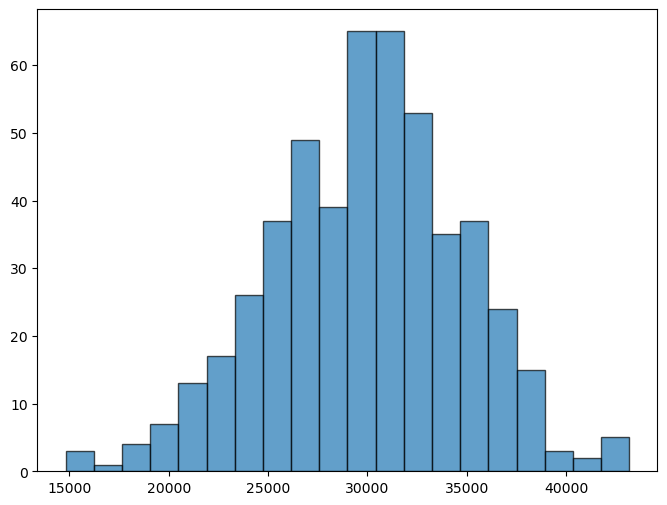

In [46]:
# Plot a histogram
plt.figure(figsize=(8, 6))
plt.hist(customers[0], bins=20, edgecolor='black', alpha=0.7)

In [48]:
customers.mean()

0    29949.879055
dtype: float64

In [50]:
customers.std()

0    4798.066392
dtype: float64

### Based on the customer margin histogram, we can assume that the data follows a normal distribution with a mean of 29,949.88 and a standard deviation of 4,798.07

# Step 3: Define parameters and simulate customer data

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta, norm

np.random.seed(42)  # to reproduce results as you mentioned in class

mu_margin = customers.mean()[0]  
sigma_margin = customers.std()[0]  

acquisition_cost = 50000
interest_rate = 0.10
num_samples = 10000

# As clv is gonna be calculated a lot, we have just created a function to reuse it
def calculate_clv(annual_margin, retention_rate, acq_cost=acquisition_cost, i=interest_rate):
    return (annual_margin * (1.0 + i)) / ((1.0 + i) - retention_rate) - acq_cost



# Step 4 and step 5: Simulate retention rate using various Beta distributions and then calculate CLV. Plotting the Whale plot

Scenario: Bell-shaped (α=2, β=2)
  Simulation-based Average CLV: 16,190.49
  Top 20% Value Concentration: 92.06%
--------------------------------------------------
Scenario: U-shaped (α=0.5, β=0.5)
  Simulation-based Average CLV: 49,653.71
  Top 20% Value Concentration: 85.67%
--------------------------------------------------
Scenario: Skewed toward 1 (α>β)
  Simulation-based Average CLV: 53,320.54
  Top 20% Value Concentration: 51.38%
--------------------------------------------------
Scenario: Skewed toward 0 (β>α)
  Simulation-based Average CLV: -7,466.88
  Top 20% Value Concentration: -34.59%
--------------------------------------------------
Scenario: Uniform (α=1, β=1)
  Simulation-based Average CLV: 28,869.13
  Top 20% Value Concentration: 92.01%
--------------------------------------------------


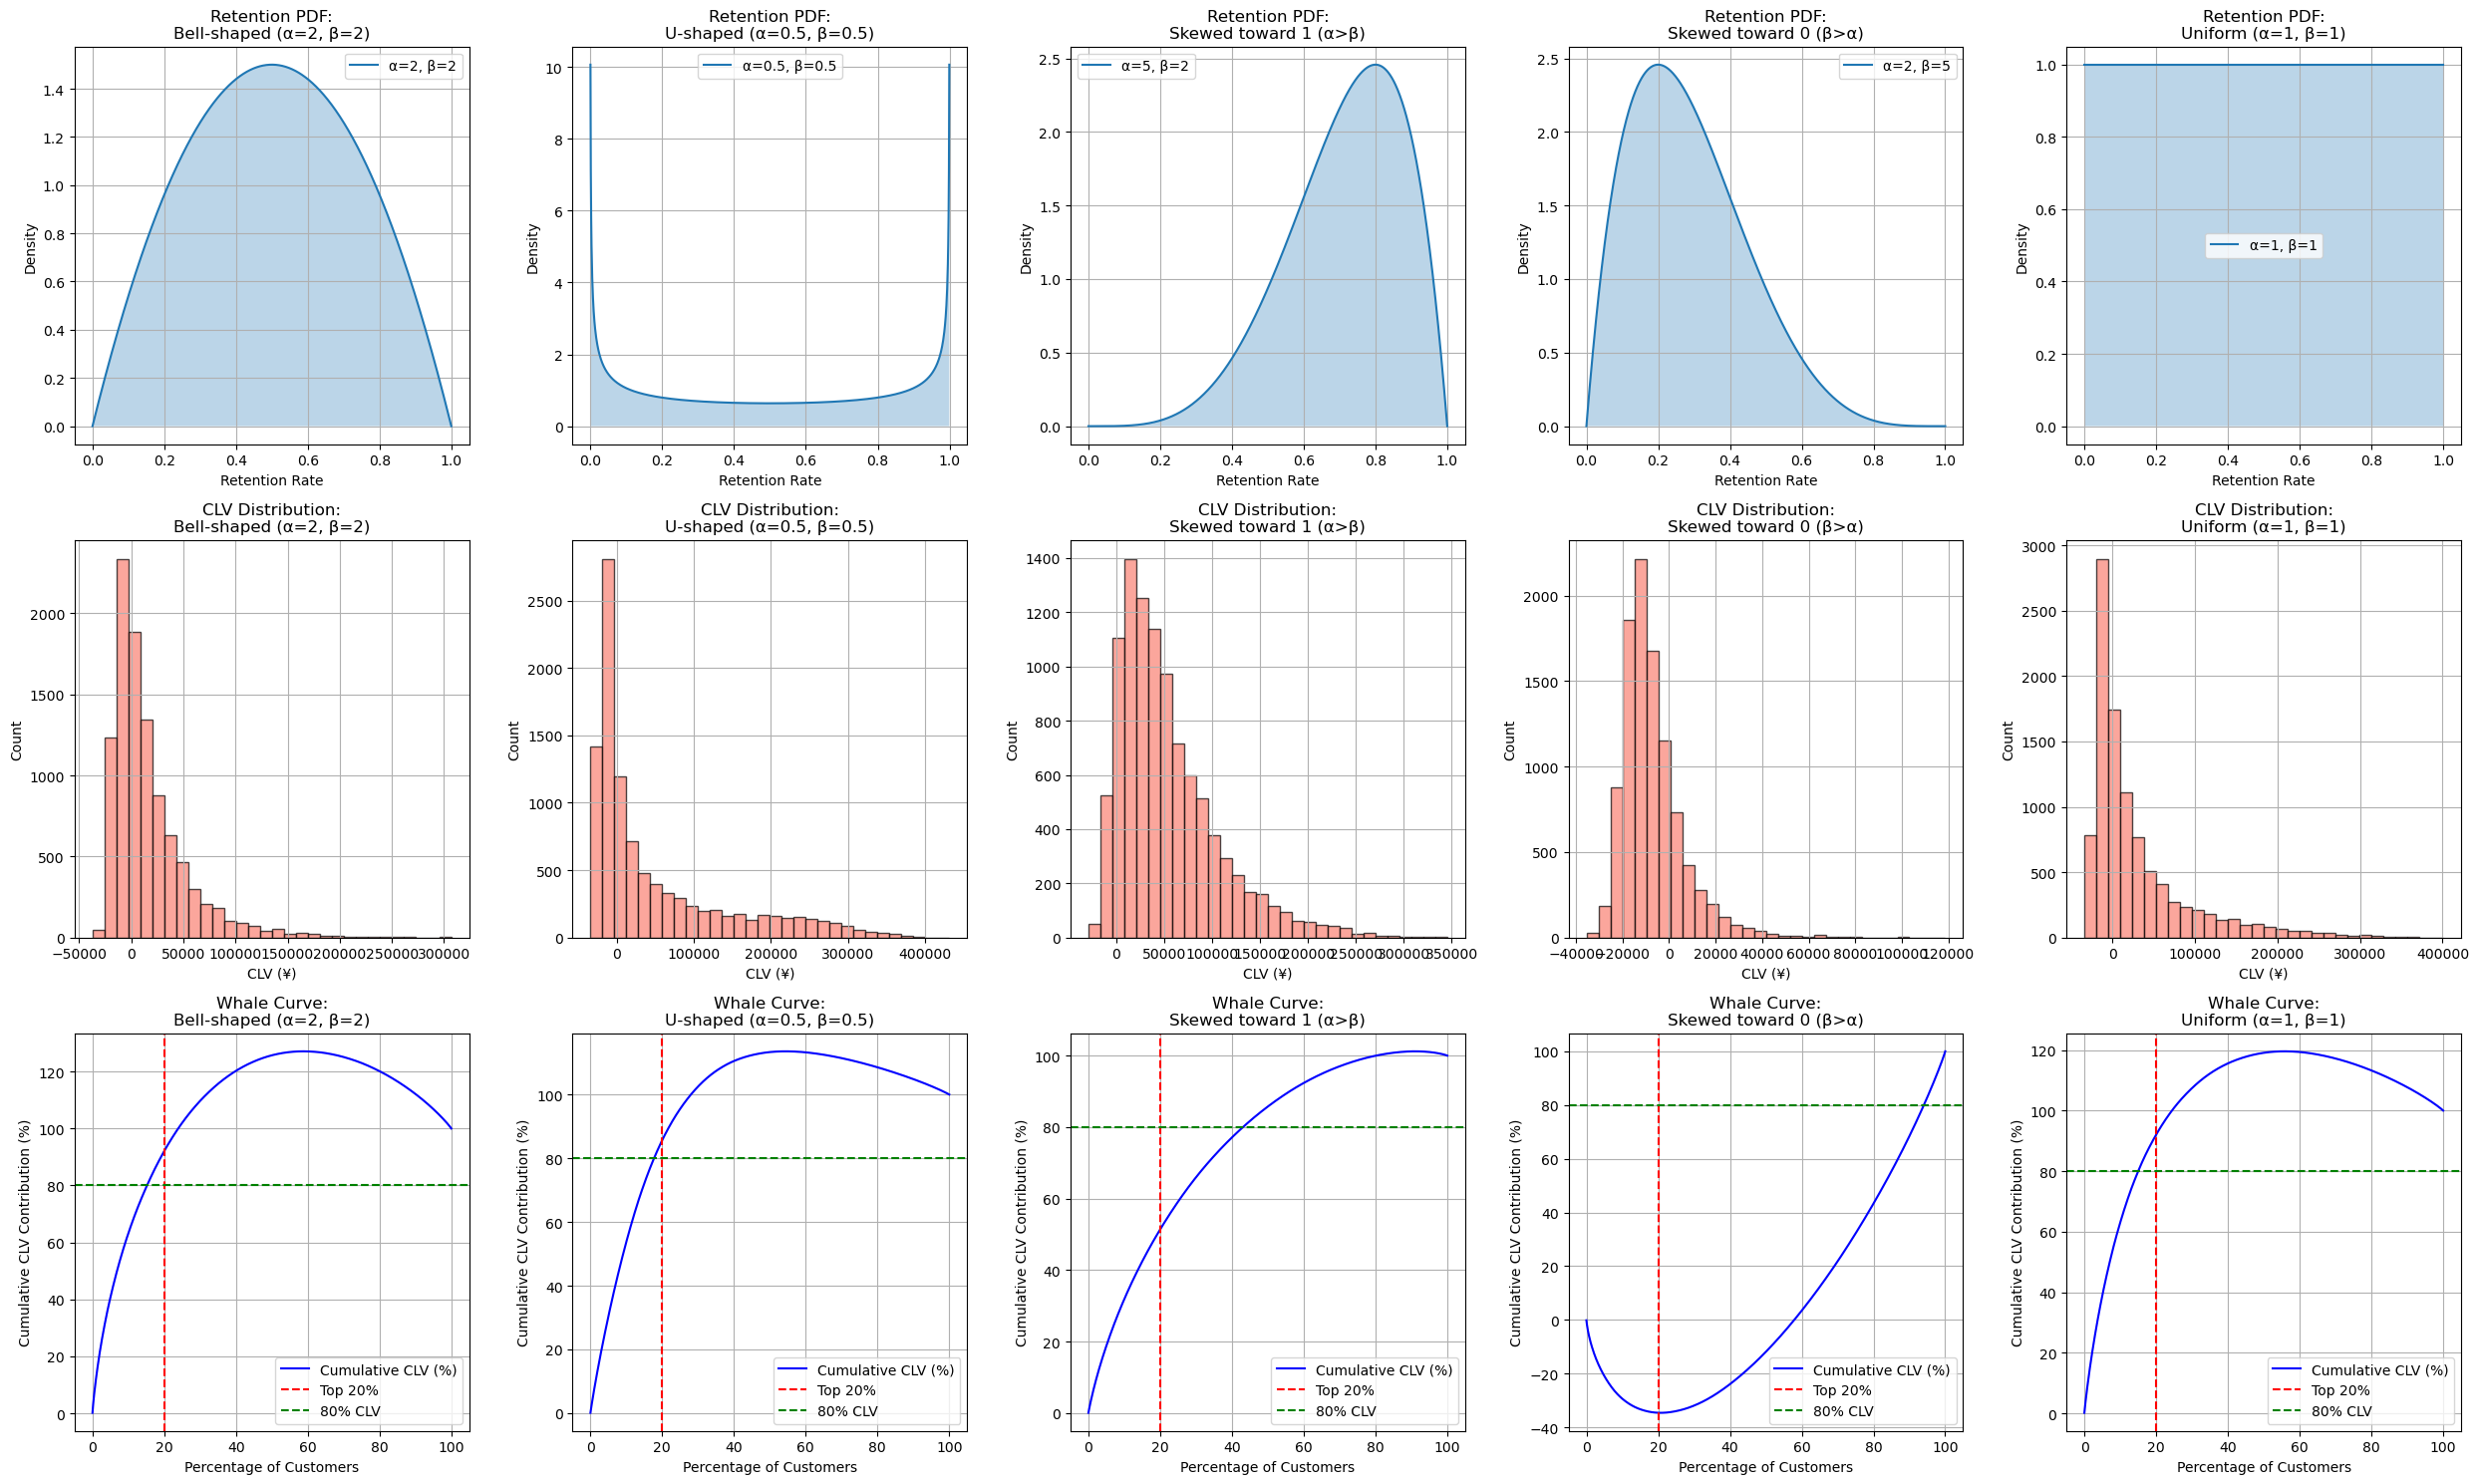

In [129]:
# Trying out multiple distribution scenarios as we saw in your reference beta ipynb file
beta_scenarios = [
    (2,   2,   "Bell-shaped (α=2, β=2)"),
    (0.5, 0.5, "U-shaped (α=0.5, β=0.5)"),
    (5,   2,   "Skewed toward 1 (α>β)"),
    (2,   5,   "Skewed toward 0 (β>α)"),
    (1,   1,   "Uniform (α=1, β=1)")
]

fig, axes = plt.subplots(3, len(beta_scenarios), figsize=(5 * len(beta_scenarios), 15))
x_vals = np.linspace(0, 1, 1000)  

simulated_margins = np.random.normal(mu_margin, sigma_margin, num_samples)

whale_data = []  
summary_stats = []  

# plotting the beta PDF
for idx, (alpha_val, beta_val, scenario_name) in enumerate(beta_scenarios):
    pdf_vals = beta.pdf(x_vals, alpha_val, beta_val)
    axes[0, idx].plot(x_vals, pdf_vals, label=f"α={alpha_val}, β={beta_val}")
    axes[0, idx].fill_between(x_vals, pdf_vals, alpha=0.3)
    axes[0, idx].set_title(f"Retention PDF:\n{scenario_name}")
    axes[0, idx].set_xlabel("Retention Rate")
    axes[0, idx].set_ylabel("Density")
    axes[0, idx].legend()
    axes[0, idx].grid(True)

    # Simulating retention and calculating CLV 
    simulated_retention = beta.rvs(alpha_val, beta_val, size=num_samples)
    clv_vals = calculate_clv(simulated_margins, simulated_retention)
    # Excluding invalid CLV values
    invalid_mask = simulated_retention >= (1.0 + interest_rate)
    clv_vals[invalid_mask] = np.nan

    valid_clv = clv_vals[~np.isnan(clv_vals)]
    axes[1, idx].hist(valid_clv, bins=30, edgecolor='black', alpha=0.7, color='salmon')
    axes[1, idx].set_title(f"CLV Distribution:\n{scenario_name}")
    axes[1, idx].set_xlabel("CLV (¥)")
    axes[1, idx].set_ylabel("Count")
    axes[1, idx].grid(True)

    # Computing summary Stats and Whale Curve for our analysis
    sim_avg_clv = np.nanmean(clv_vals)
    sorted_clv = np.sort(valid_clv)[::-1]
    cumulative_clv = np.cumsum(sorted_clv)
    total_clv = cumulative_clv[-1]
    cumulative_clv_pct = (cumulative_clv / total_clv) * 100
    top20_count = int(len(sorted_clv) * 0.20)
    top20_concentration = np.sum(sorted_clv[:top20_count]) / total_clv * 100

    print(f"Scenario: {scenario_name}")
    print(f"  Simulation-based Average CLV: {sim_avg_clv:,.2f}")
    print(f"  Top 20% Value Concentration: {top20_concentration:.2f}%")
    print("-" * 50)

    summary_stats.append((scenario_name, sim_avg_clv, top20_concentration))
    whale_data.append((scenario_name, cumulative_clv_pct, len(sorted_clv)))

    # (D) Ploting the Whale Curve
    num_valid = len(sorted_clv)
    percent_customers = np.linspace(0, 100, num_valid)
    axes[2, idx].plot(percent_customers, cumulative_clv_pct, color='blue', label="Cumulative CLV (%)")
    axes[2, idx].axvline(x=20, color='red', linestyle='--', label="Top 20%")
    axes[2, idx].axhline(y=80, color='green', linestyle='--', label="80% CLV")
    axes[2, idx].set_title(f"Whale Curve:\n{scenario_name}")
    axes[2, idx].set_xlabel("Percentage of Customers")
    axes[2, idx].set_ylabel("Cumulative CLV Contribution (%)")
    axes[2, idx].legend()
    axes[2, idx].grid(True)

plt.tight_layout()
plt.show()


Aggregate-level CLV (using mean margin 29949.88 and retention 0.60): 15,889.73
Scenario: Narrow Margin, Narrow Retention
  Simulation-based Average CLV: 19,142.52
  Top 20% Value Concentration: 52.12%
--------------------------------------------------
Scenario: Narrow Margin, Wide Retention
  Simulation-based Average CLV: 30,630.54
  Top 20% Value Concentration: 67.09%
--------------------------------------------------
Scenario: Wide Margin, Narrow Retention
  Simulation-based Average CLV: 19,071.06
  Top 20% Value Concentration: 59.87%
--------------------------------------------------
Scenario: Wide Margin, Wide Retention
  Simulation-based Average CLV: 30,425.39
  Top 20% Value Concentration: 70.46%
--------------------------------------------------


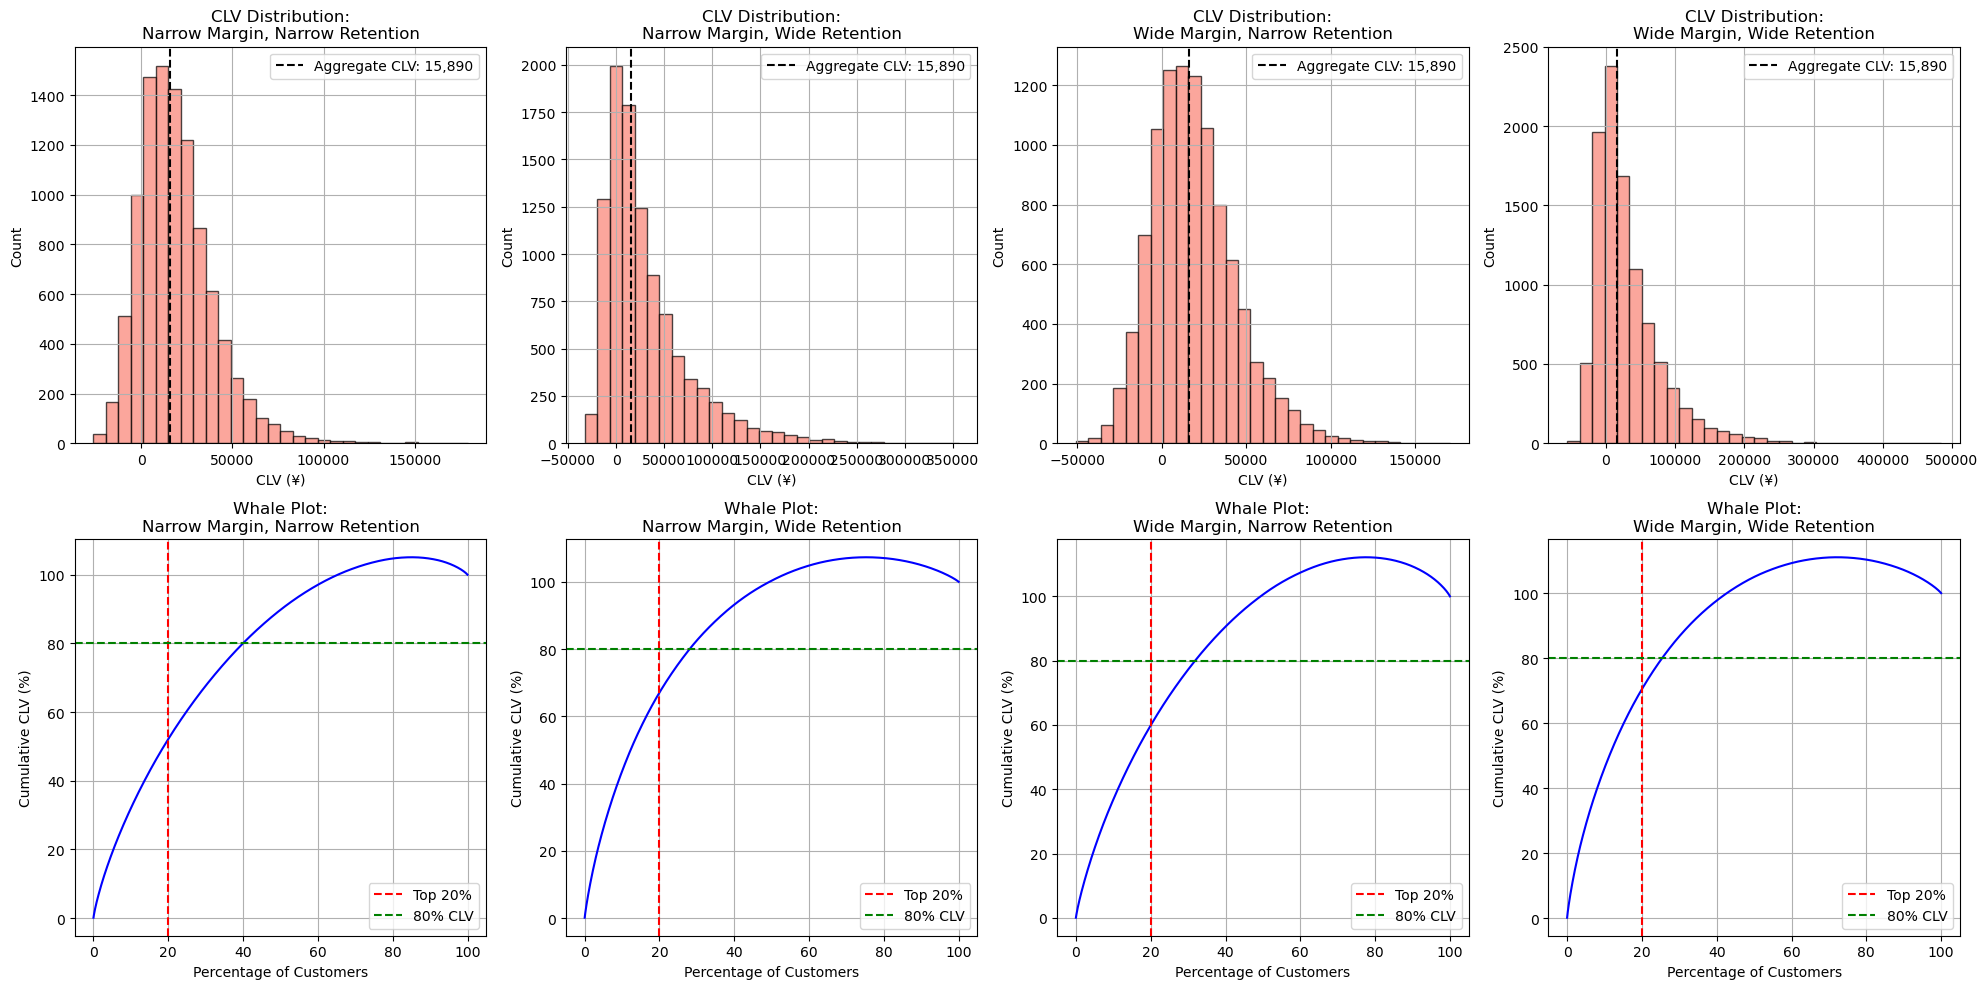

In [143]:
# Lets also take a look at how variance/spread of margin and retention affects whale curve
sigma_margin_narrow = sigma_margin_obs       # Narrow margin scenario 
sigma_margin_wide   = 8000                   # Wide margin scenario (higher variability)

retention_narrow = (12, 8)  # Tight Beta (lower variance) scenario
retention_wide   = (3, 2)   # Wider Beta (higher variance) scenario

aggregate_clv = calculate_clv(mu_margin, 0.60, acquisition_cost, interest_rate)
print(f"Aggregate-level CLV (using mean margin {mu_margin:.2f} and retention 0.60): {aggregate_clv:,.2f}")

scenarios = [
    ("Narrow Margin, Narrow Retention", sigma_margin_narrow, retention_narrow),
    ("Narrow Margin, Wide Retention",   sigma_margin_narrow, retention_wide),
    ("Wide Margin, Narrow Retention",     sigma_margin_wide, retention_narrow),
    ("Wide Margin, Wide Retention",       sigma_margin_wide, retention_wide)
]

def compute_value_concentration(clv_array, top_pct=20):
    valid_clv = clv_array[~np.isnan(clv_array)]
    sorted_clv = np.sort(valid_clv)[::-1]  # descending order
    cutoff = int(len(sorted_clv) * top_pct / 100)
    top_total = np.sum(sorted_clv[:cutoff])
    overall_total = np.sum(sorted_clv)
    return (top_total / overall_total) * 100

results = [] 

for label, margin_std, (alpha_ret, beta_ret) in scenarios:
    simulated_margins = np.random.normal(mu_margin, margin_std, num_samples)
    simulated_retention = beta.rvs(alpha_ret, beta_ret, size=num_samples)

    clv_array = calculate_clv(simulated_margins, simulated_retention, acquisition_cost, interest_rate)
    clv_array[simulated_retention >= (1 + interest_rate)] = np.nan
    sim_avg_clv = np.nanmean(clv_array)
    top20_concentration = compute_value_concentration(clv_array, top_pct=20)
    results.append((label, sim_avg_clv, top20_concentration, clv_array))

    print(f"Scenario: {label}")
    print(f"  Simulation-based Average CLV: {sim_avg_clv:,.2f}")
    print(f"  Top 20% Value Concentration: {top20_concentration:.2f}%")
    print("-" * 50)

fig, axes = plt.subplots(2, len(scenarios), figsize=(5 * len(scenarios), 10))

for idx, (label, sim_avg_clv, top20_conc, clv_array) in enumerate(results):
    valid_clv = clv_array[~np.isnan(clv_array)]
    sorted_clv = np.sort(valid_clv)[::-1]
    cumulative_clv_pct = np.cumsum(sorted_clv) / np.sum(sorted_clv) * 100
    percent_customers = np.linspace(0, 100, len(sorted_clv))
    
    # CLV Distribution
    axes[0, idx].hist(valid_clv, bins=30, color='salmon', edgecolor='black', alpha=0.7)
    axes[0, idx].axvline(aggregate_clv, color='black', linestyle='--',
                         label=f"Aggregate CLV: {aggregate_clv:,.0f}")
    axes[0, idx].set_title(f"CLV Distribution:\n{label}")
    axes[0, idx].set_xlabel("CLV (¥)")
    axes[0, idx].set_ylabel("Count")
    axes[0, idx].legend()
    axes[0, idx].grid(True)

    #Whale Curve 
    axes[1, idx].plot(percent_customers, cumulative_clv_pct, color='blue')
    axes[1, idx].axvline(x=20, color='red', linestyle='--', label="Top 20%")
    axes[1, idx].axhline(y=80, color='green', linestyle='--', label="80% CLV")
    axes[1, idx].set_title(f"Whale Plot:\n{label}")
    axes[1, idx].set_xlabel("Percentage of Customers")
    axes[1, idx].set_ylabel("Cumulative CLV (%)")
    axes[1, idx].legend()
    axes[1, idx].grid(True)

plt.tight_layout()
plt.show()
